# Business Case OLA - Ensemble Learning

### Problem Statement

Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola, focused on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like

- Demographics (city, age, gender etc.)
- Tenure information (joining date, Last Date)
- Historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

### Column Profiling:

- MMMM-YY : Reporting Date (Monthly)
- Driver_ID : Unique id for drivers
- Age : Age of the driver
- Gender : Gender of the driver – Male : 0, Female: 1
- City : City Code of the driver
- Education_Level : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate
- Income : Monthly average Income of the driver
- Date Of Joining : Joining date for the driver
- LastWorkingDate : Last date of working for the driver
- Joining Designation : Designation of the driver at the time of joining
- Grade : Grade of the driver at the time of reporting
- Total Business Value : The total business value acquired by the driver in a month (negative business indicates cancellation/refund or car EMI adjustments)
- Quarterly Rating : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier

In [2]:
# Importing the data

data = pd.read_csv(r"D:\Scaler\11 ML  Supervised Algorithms\Business Case Study\01 Business Case OLA - Ensemble Learning\ola_driver_scaler.csv")

In [3]:
data.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [4]:
data.drop(columns='Unnamed: 0',inplace=True)

In [5]:
df_data = data.copy()

In [6]:
data.head()

,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


# 1. Define Problem Statement and perform Exploratory Data Analysis (10 points)
- Definition of problem (as per given problem statement with additional views)
- Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary.
- Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)
- Bivariate Analysis (Relationships between important variables)
- Illustrate the insights based on EDA
    - Comments on range of attributes, outliers of various attributes
    - Comments on the distribution of the variables and relationship between them
    - Comments for each univariate and bivariate plots

In [7]:
# Shape of the data

print("Shape of the dataset:", data.shape)
print("\nData Types:\n", data.dtypes)

# Display the first few rows

data.head()

Shape of the dataset: (19104, 13)

Data Types:
 MMM-YY                   object
Driver_ID                 int64
Age                     float64
Gender                  float64
City                     object
Education_Level           int64
Income                    int64
Dateofjoining            object
LastWorkingDate          object
Joining Designation       int64
Grade                     int64
Total Business Value      int64
Quarterly Rating          int64
dtype: object


,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [8]:
# Convert object-type columns that are actually categorical to 'category'

categorical_cols = ['City']
for col in categorical_cols:
    data[col] = data[col].astype('category')

# Convert encoded numerical categorical columns to 'category'

encoded_cat_cols = ['Gender', 'Education_Level', 'Joining Designation']
for col in encoded_cat_cols:
    data[col] = data[col].astype('category')

In [9]:
# Check for missing values

missing_values = data.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 MMM-YY                      0
Driver_ID                   0
Age                        61
Gender                     52
City                        0
Education_Level             0
Income                      0
Dateofjoining               0
LastWorkingDate         17488
Joining Designation         0
Grade                       0
Total Business Value        0
Quarterly Rating            0
dtype: int64


In [10]:
# Descriptive stats for numerical and categorical

print("\nNumerical Summary:\n")
data.describe()


Numerical Summary:



,Driver_ID,Age,Income,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19043.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.668435,65652.025126,2.252670,5.716621e+05,2.008899
std,810.705321,6.257912,30914.515344,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,10747.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,42383.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,60087.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,83969.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,188418.000000,5.000000,3.374772e+07,4.000000


In [11]:
print("\nCategorical Summary:\n") 
data.describe(include=['category'])


Categorical Summary:



,Gender,City,Education_Level,Joining Designation
count,19052.0,19104,19104,19104
unique,2.0,29,3,5
top,0.0,C20,1,1
freq,11074.0,1008,6864,9831


In [12]:
data.dtypes

MMM-YY                    object
Driver_ID                  int64
Age                      float64
Gender                  category
City                    category
Education_Level         category
Income                     int64
Dateofjoining             object
LastWorkingDate           object
Joining Designation     category
Grade                      int64
Total Business Value       int64
Quarterly Rating           int64
dtype: object

In [13]:
# Convert date fields to datetime

data['Dateofjoining'] = pd.to_datetime(data['Dateofjoining'], dayfirst=True)
data['LastWorkingDate'] = pd.to_datetime(data['LastWorkingDate'], dayfirst=True)

In [14]:
data['Driver_ID'].duplicated().sum()

16723

In [15]:
data.columns

Index(['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level',
       'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation',
       'Grade', 'Total Business Value', 'Quarterly Rating'],
      dtype='object')

In [16]:
agg_funcs = {
    'Age': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'Gender': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'City': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'Education_Level': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'Income': 'mean',
    'Dateofjoining': 'min', 
    'LastWorkingDate': 'max',
    'Joining Designation': lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan,
    'Grade': 'mean',
    'Total Business Value': 'sum',
    'Quarterly Rating': 'mean',
    'MMM-YY': 'min'
}

In [17]:
# Group by Driver_ID and Aggregate

df = data.groupby('Driver_ID').agg(agg_funcs).reset_index()

In [18]:
# Shape of the data

print("Shape of the dataset:", df.shape)
print("\nData Types:\n", df.dtypes)

# Display the first few rows

df.head()

Shape of the dataset: (2381, 13)

Data Types:
 Driver_ID                        int64
Age                            float64
Gender                         float64
City                            object
Education_Level                  int64
Income                         float64
Dateofjoining           datetime64[ns]
LastWorkingDate         datetime64[ns]
Joining Designation              int64
Grade                          float64
Total Business Value             int64
Quarterly Rating               float64
MMM-YY                          object
dtype: object


,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,MMM-YY
0,1,28.0,0.0,C23,2,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0,01/01/19
1,2,31.0,0.0,C7,2,67016.0,2020-06-11,NaT,2,2.0,0,1.0,11/01/20
2,4,43.0,0.0,C13,2,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0,01/01/20
3,5,29.0,0.0,C9,0,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0,01/01/19
4,6,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3.0,1265000,1.6,08/01/20


In [19]:
# Check for missing values

missing_values = df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 Driver_ID                 0
Age                       0
Gender                    0
City                      0
Education_Level           0
Income                    0
Dateofjoining             0
LastWorkingDate         765
Joining Designation       0
Grade                     0
Total Business Value      0
Quarterly Rating          0
MMM-YY                    0
dtype: int64


In [20]:
# Descriptive stats for numerical and categorical

print("\nNumerical Summary:\n")
df.describe()


Numerical Summary:



,Driver_ID,Age,Gender,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,2381.000000,2381.000000,2381.000000,2381.00000,2381.000000,2381,1616,2381.000000,2381.000000,2.381000e+03,2381.000000
mean,1397.559009,33.350273,0.410332,1.00756,59232.460484,2019-01-27 12:58:58.009239808,2019-12-26 23:22:34.455445760,1.820244,2.081713,4.586742e+06,1.566304
min,1.000000,21.000000,0.000000,0.00000,10747.000000,2013-01-04 00:00:00,2018-12-31 00:00:00,1.000000,1.000000,-1.385530e+06,1.000000
25%,695.000000,29.000000,0.000000,0.00000,39104.000000,2018-06-26 00:00:00,2019-06-10 00:00:00,1.000000,1.000000,0.000000e+00,1.000000
50%,1400.000000,33.000000,0.000000,1.00000,55285.000000,2019-06-23 00:00:00,2019-12-20 12:00:00,2.000000,2.000000,8.176800e+05,1.000000
75%,2100.000000,37.000000,1.000000,2.00000,75835.000000,2020-04-14 00:00:00,2020-07-14 00:00:00,2.000000,3.000000,4.173650e+06,2.000000
max,2788.000000,58.000000,1.000000,2.00000,188418.000000,2020-12-28 00:00:00,2020-12-28 00:00:00,5.000000,5.000000,9.533106e+07,4.000000
std,806.161628,5.894944,0.491997,0.81629,28298.214012,NaN,NaN,0.841433,0.932257,9.127115e+06,0.719652


In [21]:
df.dtypes

Driver_ID                        int64
Age                            float64
Gender                         float64
City                            object
Education_Level                  int64
Income                         float64
Dateofjoining           datetime64[ns]
LastWorkingDate         datetime64[ns]
Joining Designation              int64
Grade                          float64
Total Business Value             int64
Quarterly Rating               float64
MMM-YY                          object
dtype: object

In [22]:
# Target column: 1 if driver has left (LastWorkingDate not null), else 0

df['Attrition'] = df['LastWorkingDate'].notnull().astype(int)

# Check balance of the target

print("\nAttrition Distribution:\n", df['Attrition'].value_counts())


Attrition Distribution:
 Attrition
1    1616
0     765
Name: count, dtype: int64


In [23]:
categorical_cols = ['Gender', 'Education_Level', 'City', 'Joining Designation', 'Grade']
continuous_cols = ['Age', 'Income', 'Total Business Value', 'Quarterly Rating']

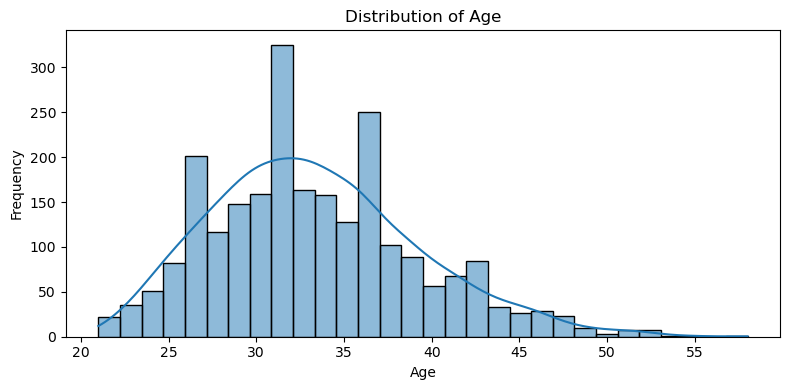

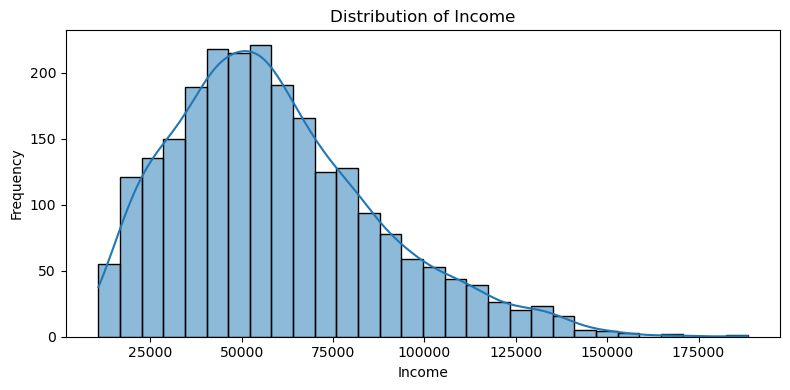

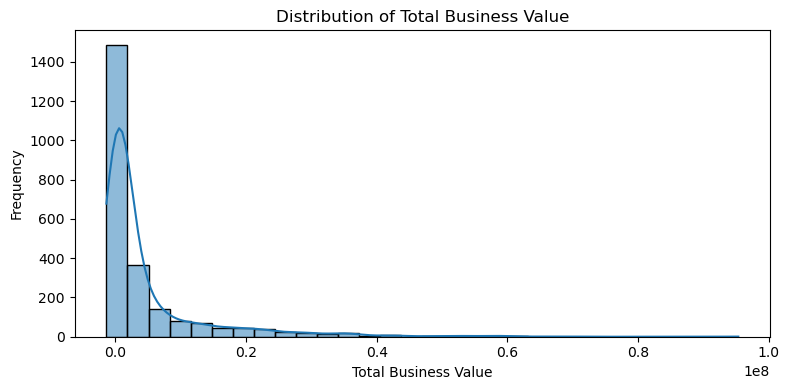

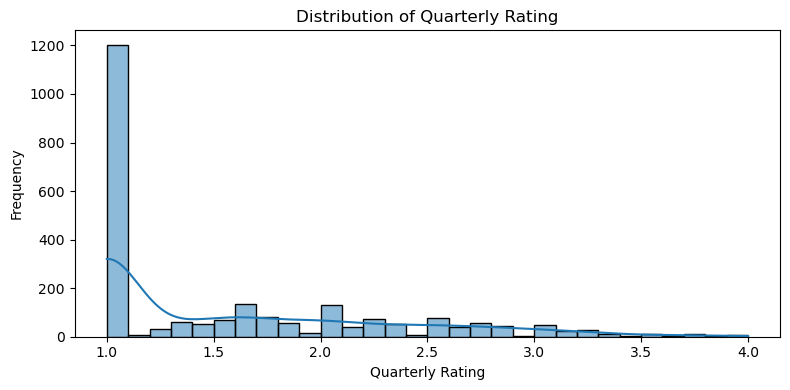

In [24]:
# Continuous Variables — Distribution Plots
# Distribution plots

for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

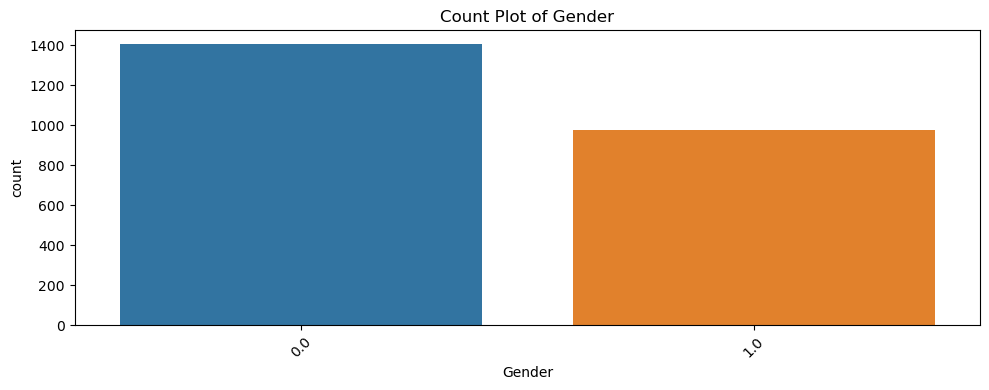

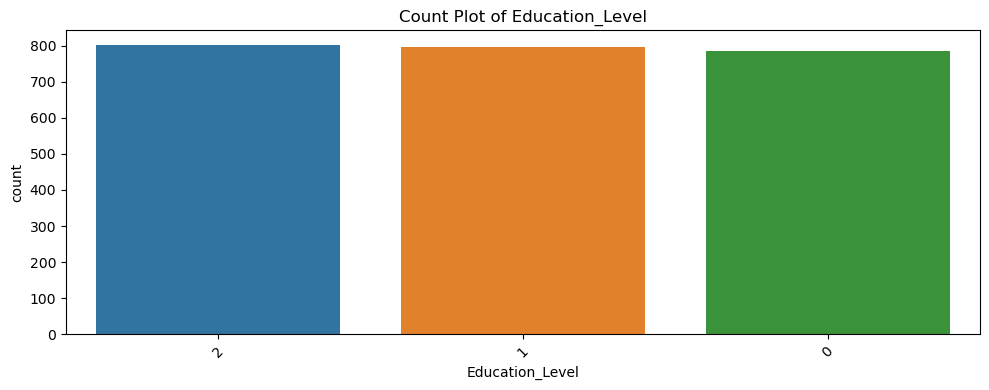

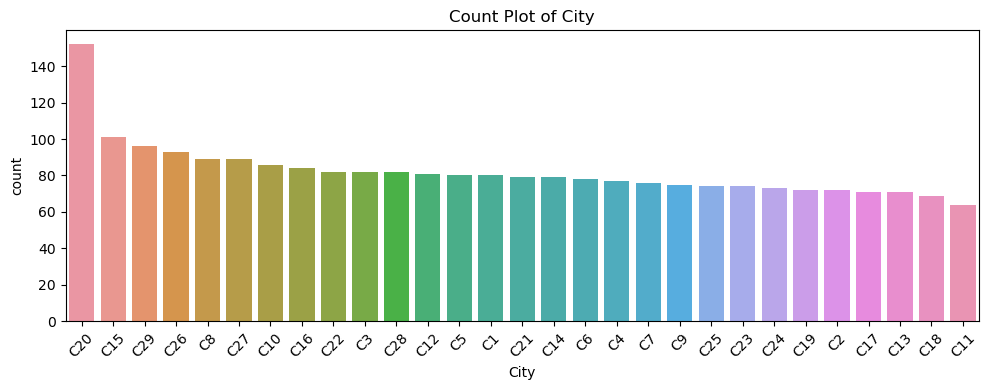

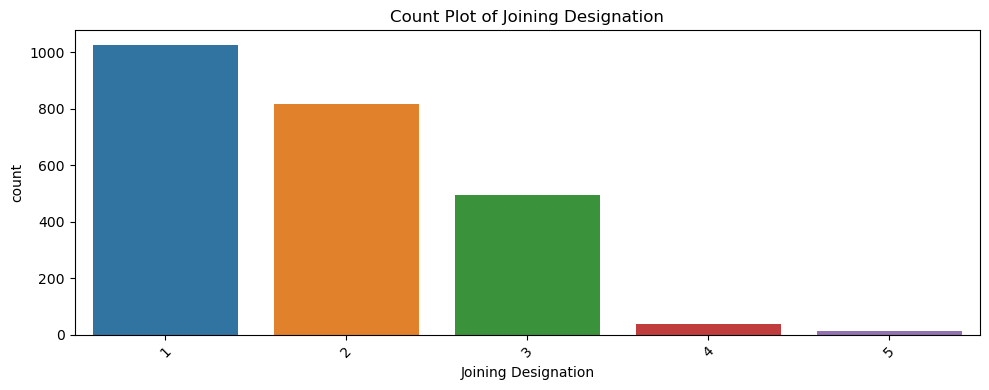

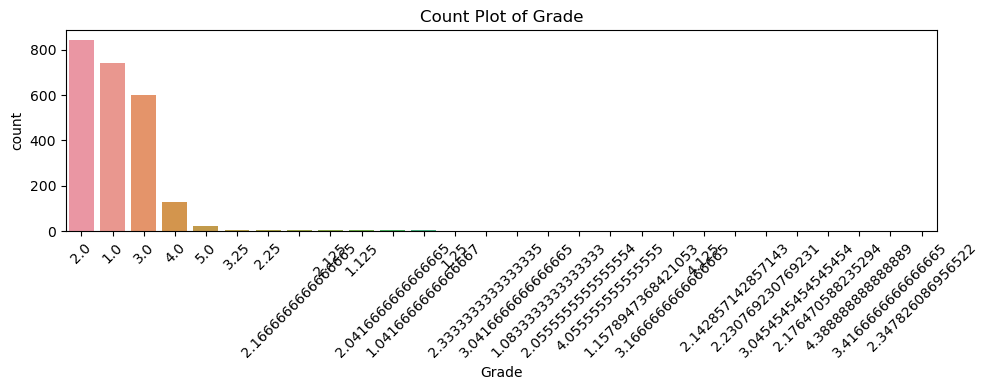

In [25]:
# Categorical variables - Count Plots
# Count plots

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

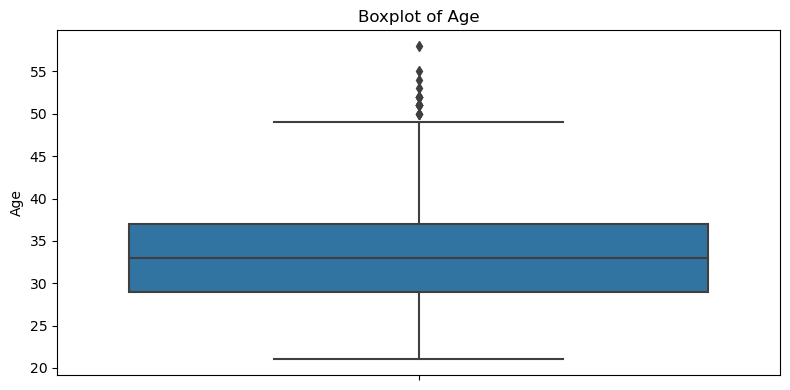

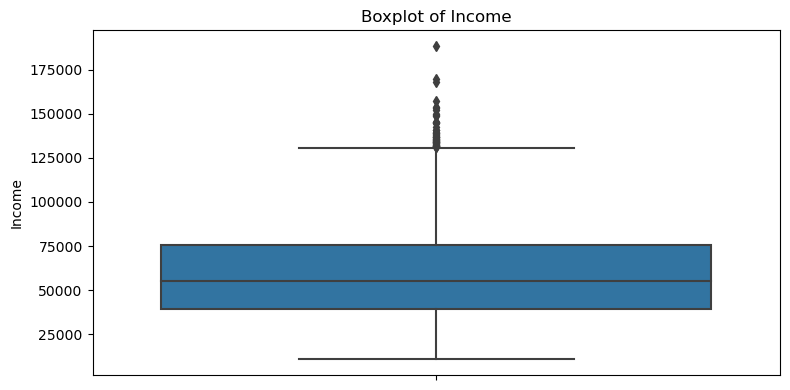

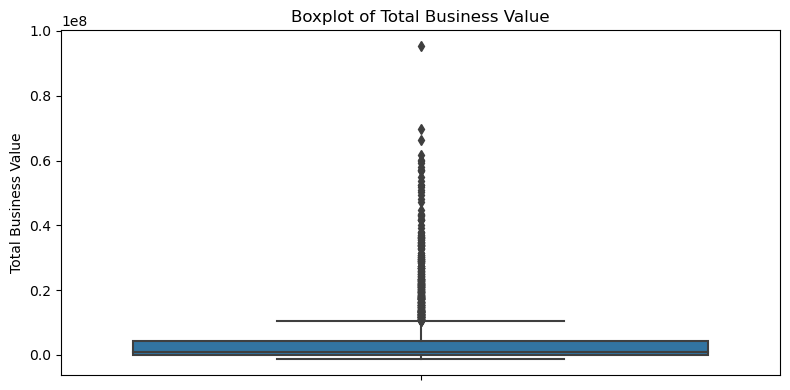

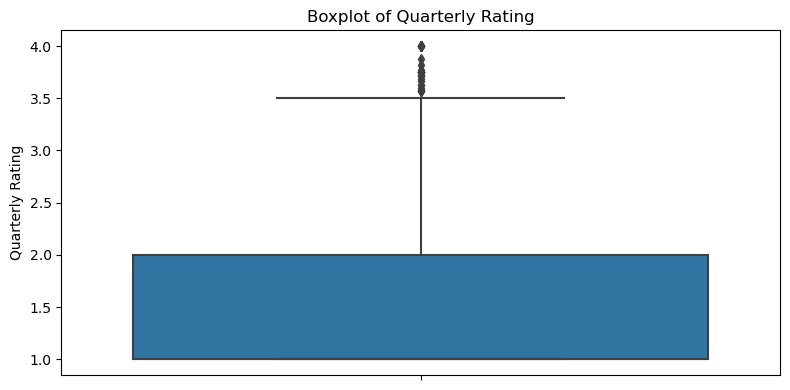

In [26]:
# Boxplots for each continuous variable

for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

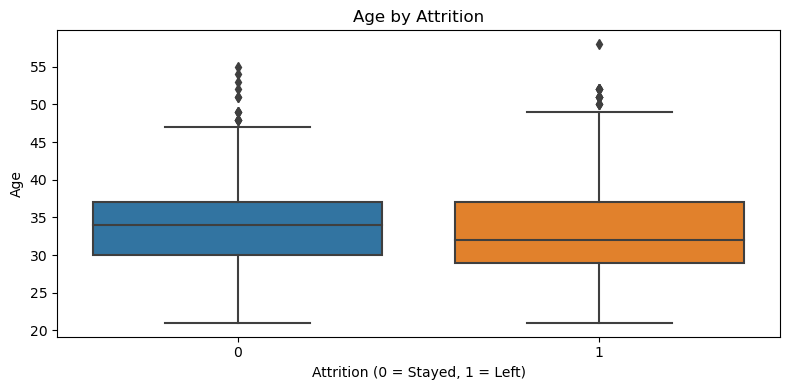

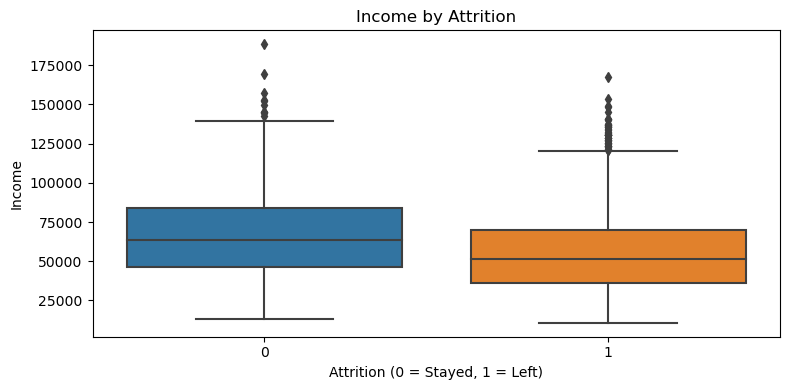

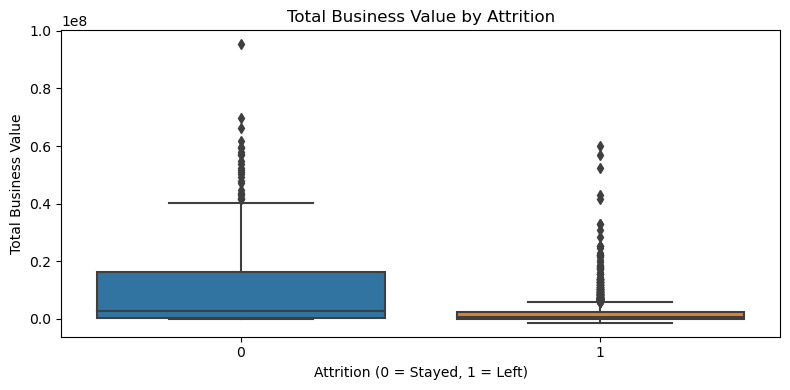

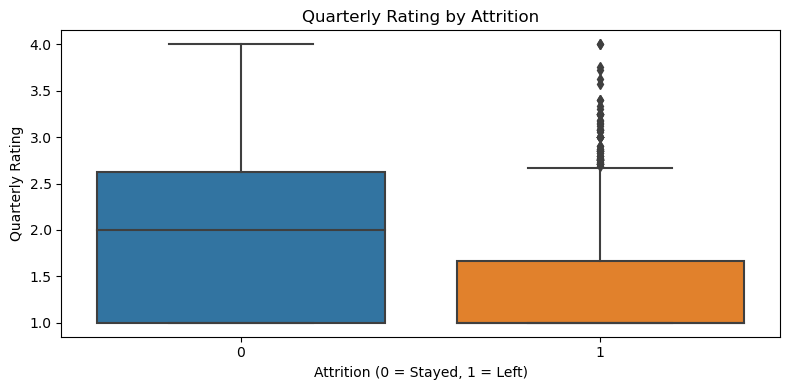

In [27]:
# Boxplots grouped by Attrition

for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Attrition', y=col)
    plt.title(f'{col} by Attrition')
    plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
    plt.tight_layout()
    plt.show()

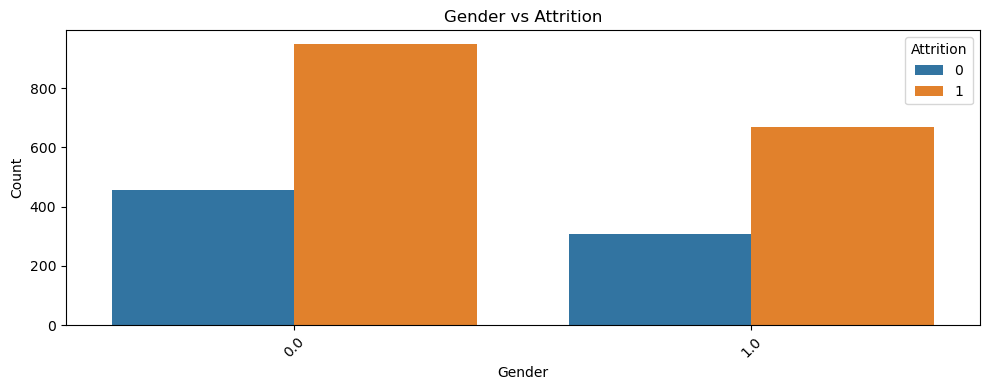

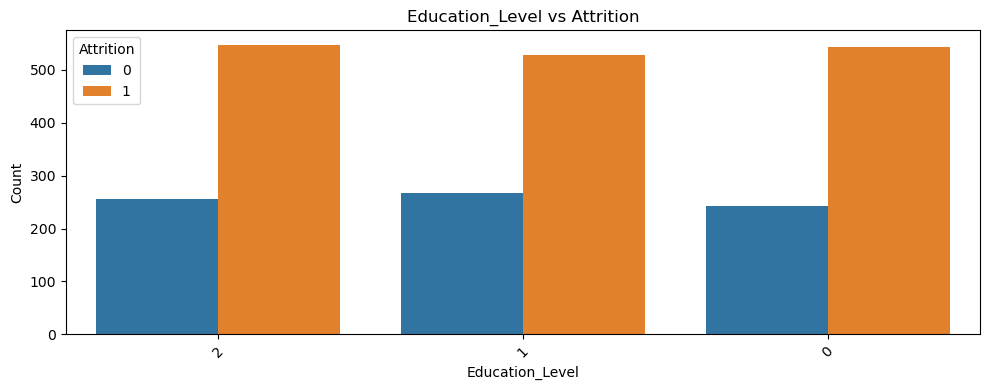

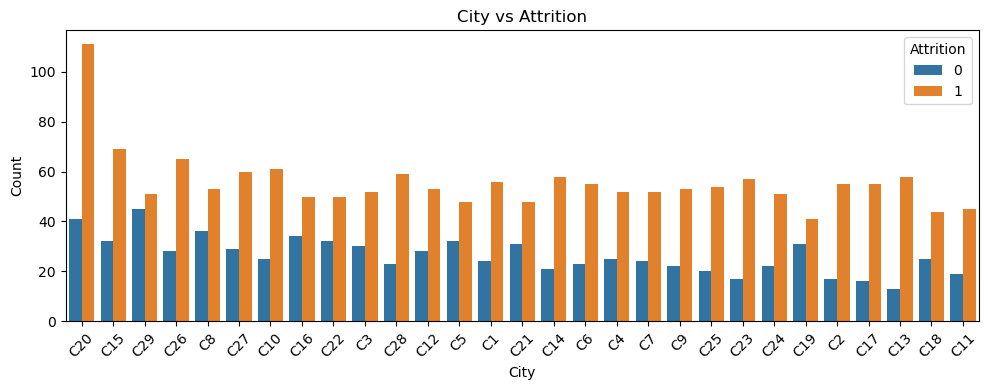

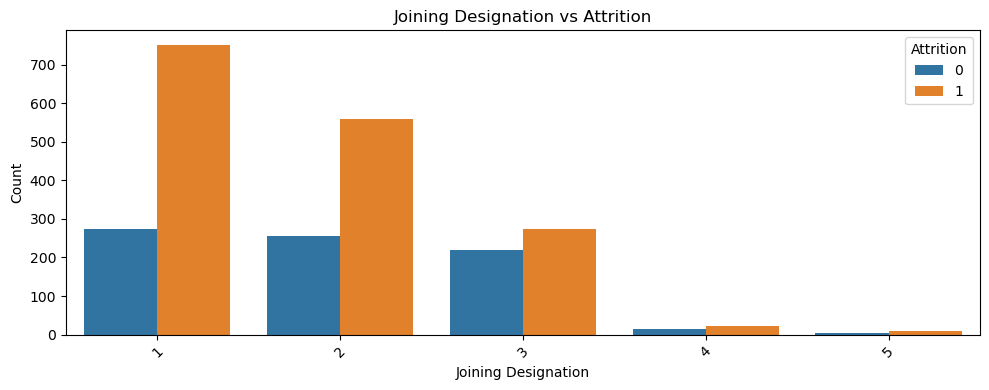

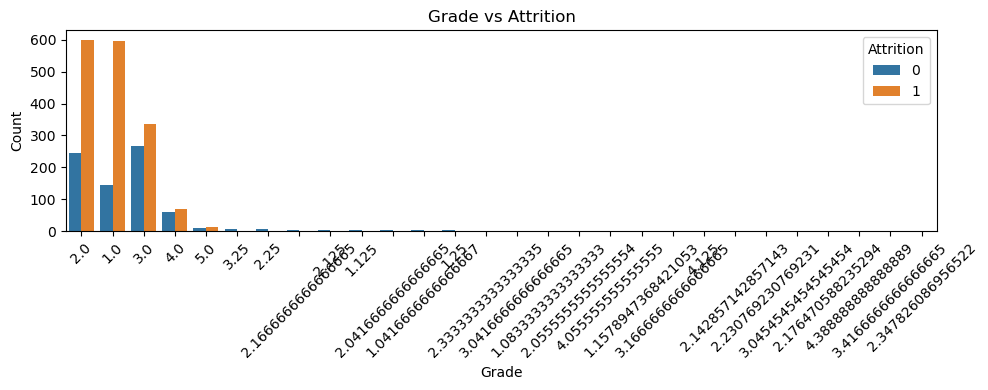

In [28]:
# Categorical vs Categorical (Countplot with hue=Attrition)

for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=df, x=col, hue='Attrition', order=df[col].value_counts().index)
    plt.title(f'{col} vs Attrition')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

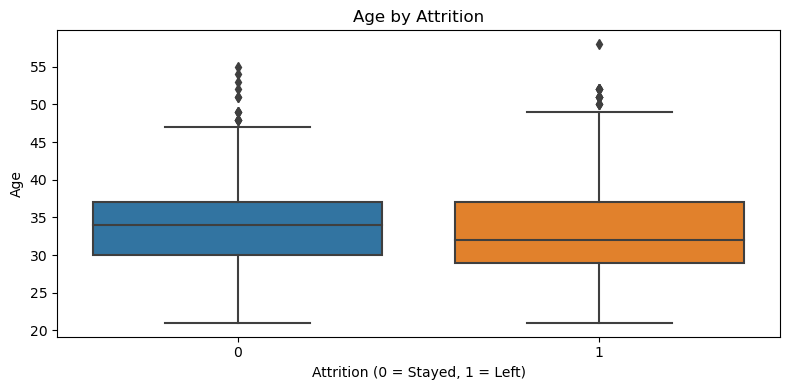

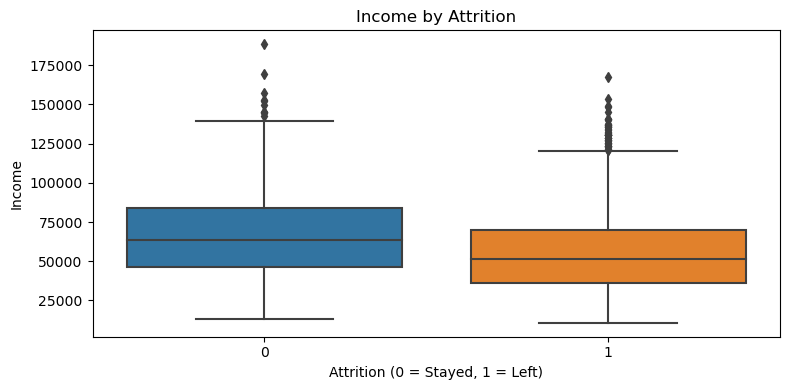

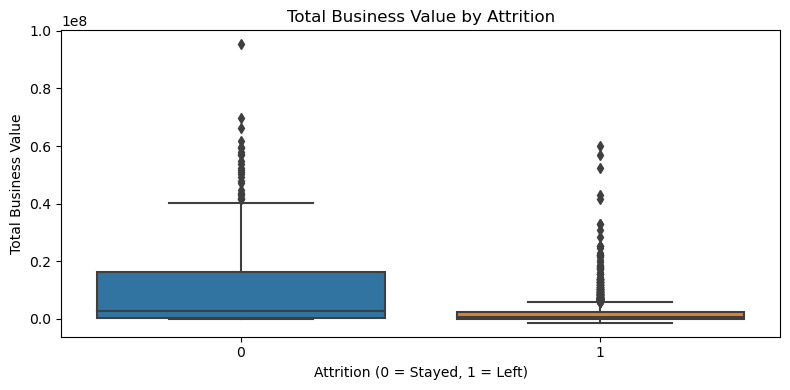

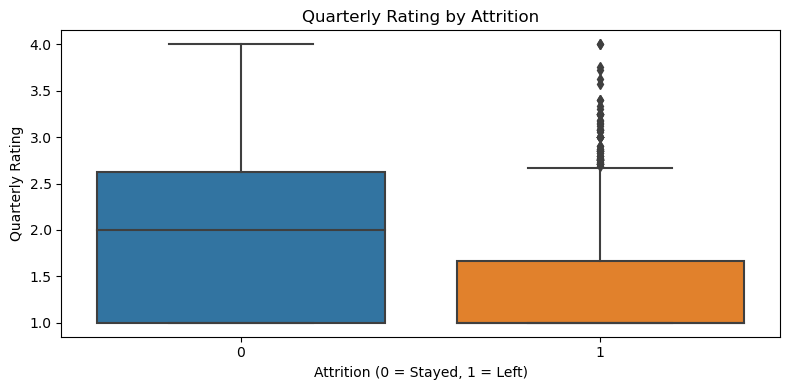

In [29]:
# Continuous vs Attrition (Boxplot)

for col in continuous_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Attrition', y=col)
    plt.title(f'{col} by Attrition')
    plt.xlabel('Attrition (0 = Stayed, 1 = Left)')
    plt.tight_layout()
    plt.show()

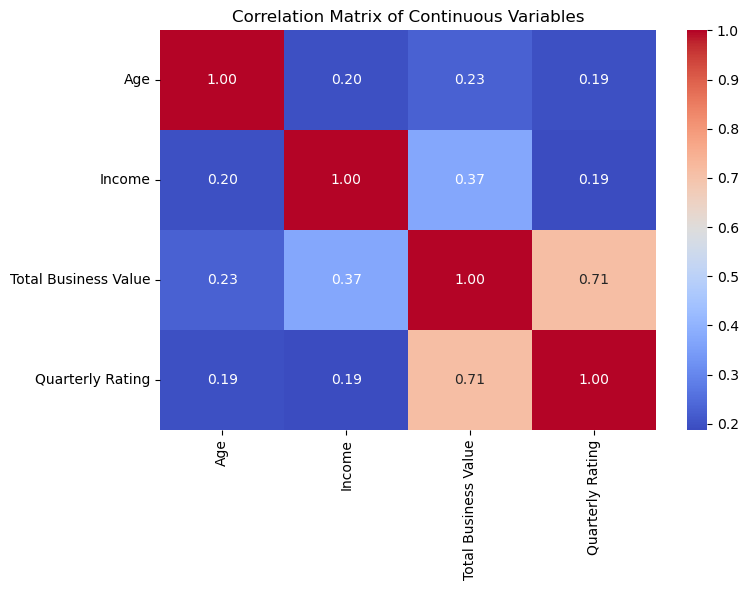

In [30]:
# Heatmap of correlations between continuous variables

plt.figure(figsize=(8, 6))
sns.heatmap(df[continuous_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Continuous Variables')
plt.tight_layout()
plt.show()

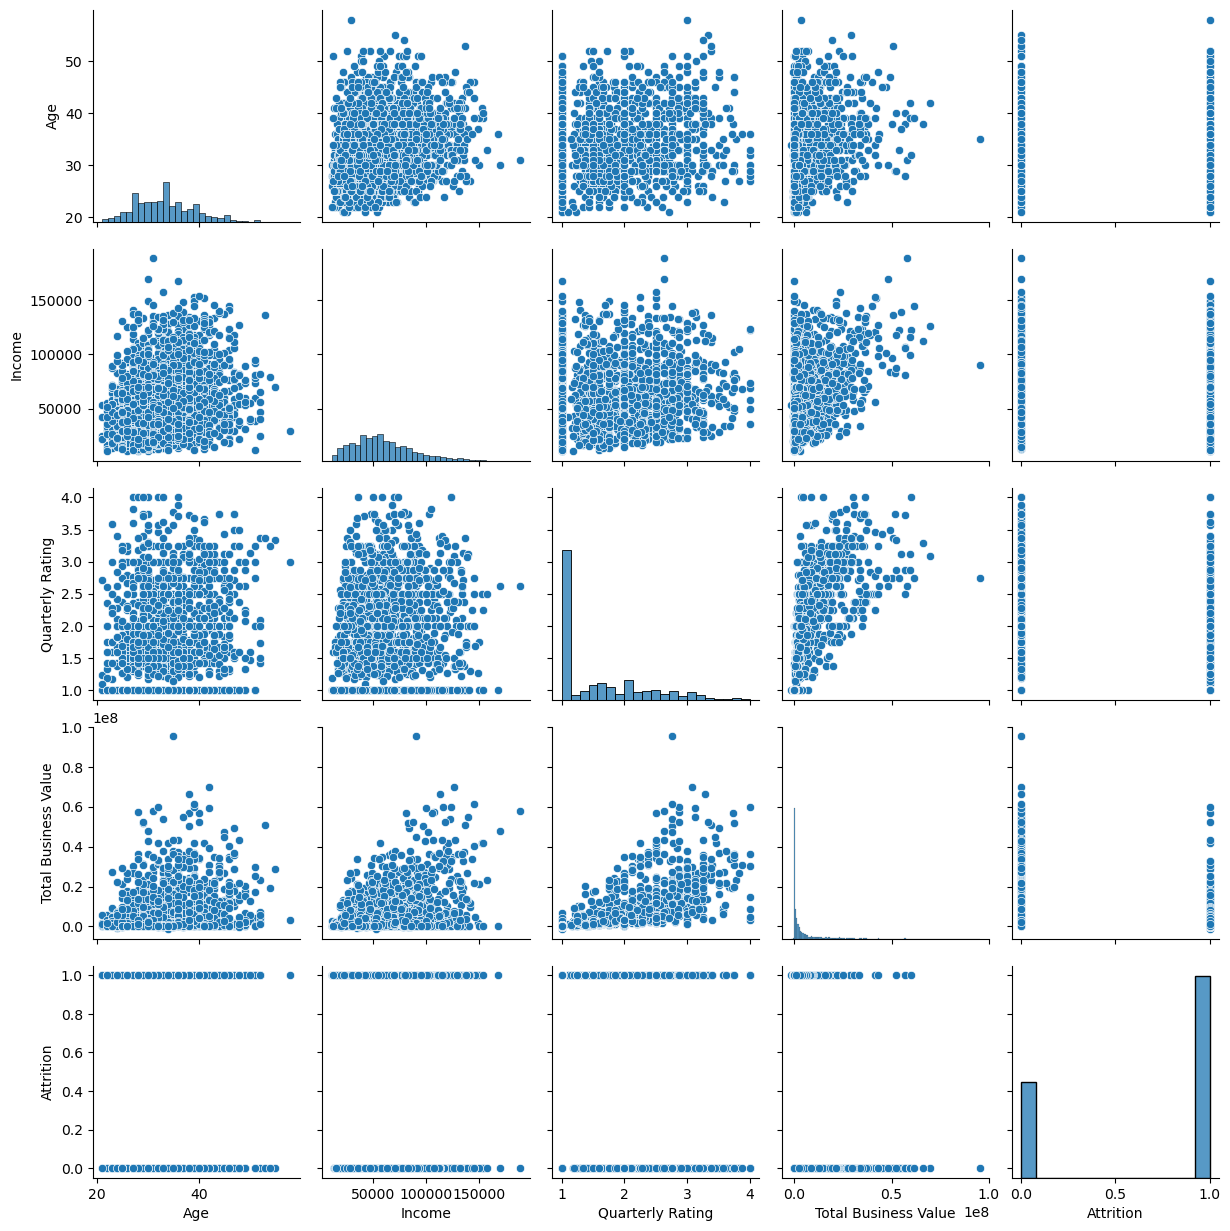

In [31]:
# Pairplot

sns.pairplot(df[['Age', 'Income', 'Quarterly Rating', 'Total Business Value', 'Attrition']])
plt.show()

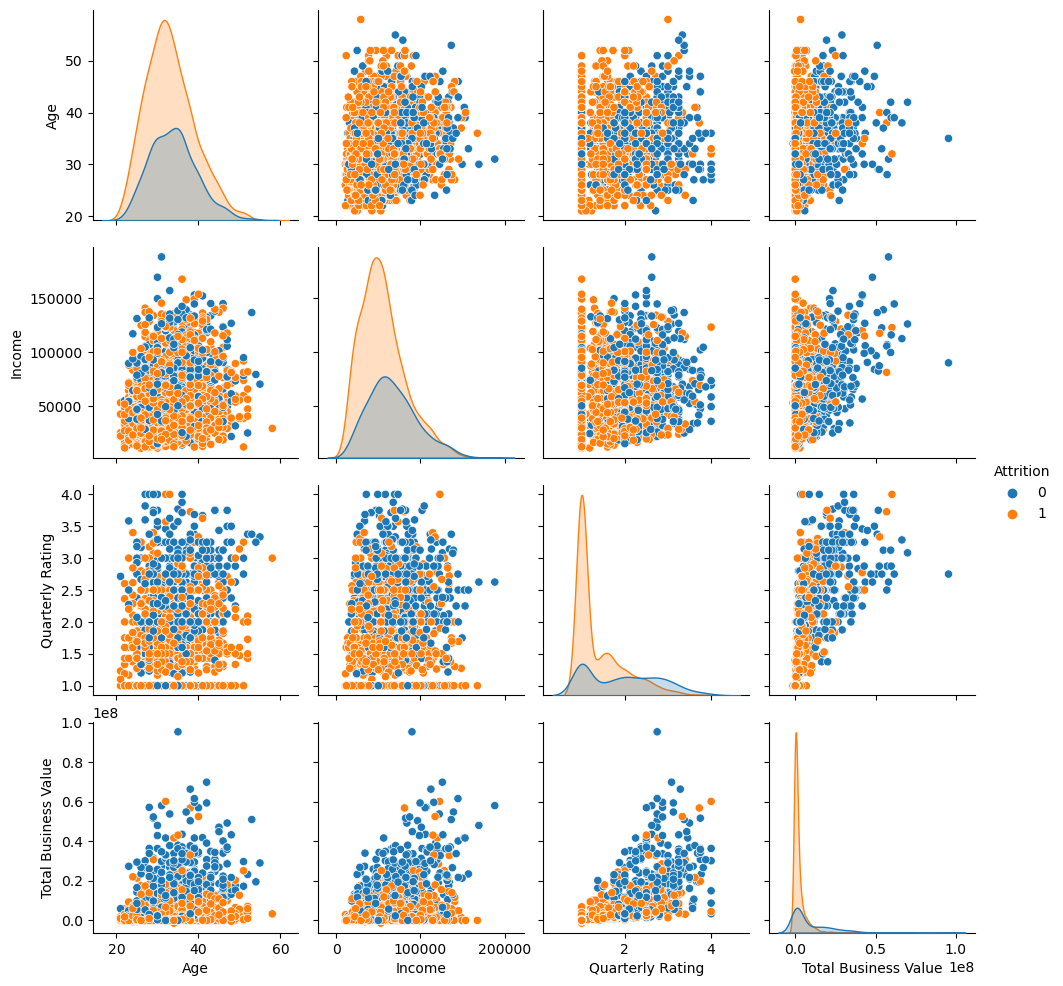

In [32]:
# Pairplot (subset to avoid high load)

sns.pairplot(df[['Age', 'Income', 'Quarterly Rating', 'Total Business Value', 'Attrition']], hue='Attrition', diag_kind='kde')
plt.show()

### Comments on range of attributes, outliers of various attributes

1. Distribution & Ranges of Continuous Variables
    - Age

        * Range: Typically between 20 and 60

        * Insights: Majority of drivers fall in the mid-age range (25–40).

        * Outliers: If you see ages below 20 or above 60, they could be flagged as data quality issues.

    - Income

        * Range: Varies widely. Check the boxplot — some values may go extremely high.

        * Insights: Income distribution may be right-skewed. Most drivers earn in a middle band, with a few high earners (likely outliers).

        * Outliers: Very high-income values may skew the mean — you might consider using log transformation or Winsorization.

    - Quarterly Rating

        * Range: 1 to 5 (by definition)

        * Insights: Most drivers hover between 3 to 4. High ratings are associated with lower attrition.

    - Total Business Value

        * Range: Can go negative (cancellations/EMI adjustments)

        * Insights: Majority of drivers have moderate business values. Drivers with negative values could be struggling or inactive.

        * Outliers: Watch for very large positive or negative values.

2. Categorical Variables Insights
    - Gender

        * Dominated by one category (likely male = 0).

        * Female drivers might be underrepresented — consider this in model fairness.

    - City

        * Check for city-wise attrition variation. Some cities might have higher churn due to operational differences.

    - Education_Level

        * Graduates (2) may churn less — possibly due to better job satisfaction or opportunities.

    - Joining Designation

        * If there's imbalance (e.g. too many drivers from 1-2 designations), impact on attrition could vary.

    - Grade

        * Higher grade → possibly more experience or better drivers → possibly lower attrition.

3. Attrition Patterns
    - Overall Distribution: You’ve created a binary attrition variable — great.

    - Patterns:

        - Lower Quarterly Rating and Total Business Value → higher attrition

        - Higher Income → lower attrition

        - City and education level also show some effect on churn behavior.

### Comments on the distribution of the variables and relationship between them

* Distribution of Variables
    1. Age
        * Shape: Normal-like distribution, slightly right-skewed.

        * Peak: Most drivers are aged between 30 and 40 years.

        * Insight: Ola’s driver base is primarily mid-aged; very few younger (<25) or older (>55) drivers.

    2. Income
        * Shape: Strong right skew.

        * Typical Range: ₹20,000–₹40,000.

        * Outliers: Several drivers with very high incomes (₹100k+).

        * Insight: Income variability could stem from performance-based incentives, city rates, or seniority.

    3. Total Business Value
        * Shape: Right-skewed with a wide spread; includes negative values.

        * Insight: Negative values may reflect deductions, penalties, or refunds. High values represent star performers.

        * Outliers: Present, with a long tail indicating few top contributors.

    4. Quarterly Rating
        * Shape: Slight skew; most ratings are between 3 and 4.

        * Observation: No drivers received a 5 — suggests either a cap or strict rating norms.

        * Insight: Indicates controlled evaluation standards, with most drivers rated similarly.

    5. Categorical Variables
        * Gender: Slight male dominance; females are underrepresented.

        * Education_Level: Majority are 12th pass or graduates; lower advanced degrees.

        * City: Dominated by a few cities (e.g., C20, C5, C10) — others have lower representation.

        * Grade & Joining Designation: Lower levels are most common, possibly linked to attrition or entry-level hiring bias.

2. Relationship Between Variables
    1. Attrition vs Other Variables
        * Income: Higher income is associated with lower attrition — better pay retains drivers.

        * Quarterly Rating: Higher ratings correlate with retention, suggesting good performers are more satisfied.

        * City: Cities like C20 show higher attrition — possibly due to poor working conditions, competition, or cost of living.

        * Education Level & Gender: Minimal direct correlation with attrition, but can interact with other variables (e.g., city or role).

    2. Inter-variable Relationships
        * Age vs Income: Mild positive correlation — older drivers tend to earn more, likely due to experience or tenure.

        * Quarterly Rating vs Business Value: Moderate positive link — top contributors are better rated.

        * Income vs Business Value: Strong correlation — drivers who generate more business also earn more.

### Comments for each univariate and bivariate plots

* Univariate Plot Comments
    1. Continuous Variables
        1. Age
            * Distribution shows a slight right skew.

            * Most drivers are in their 30s and 40s.

            * Very few young (<25) or senior (>55) drivers.

            * Indicates a relatively mature workforce.

        2. Income
            * Strong right-skewed distribution.

            * Majority earn between ₹20k–₹40k.

            * Long tail with a few high earners (>₹100k).

            * Highlights high variance and potential performance-linked incentives.

        3. Total Business Value
            * Wide spread with a long right tail.

            * Negative values indicate possible penalties, cancellations, or deductions.

            * Some drivers contribute significantly more to business than others.

        4. Quarterly Rating
            * Distribution is concentrated around 3–4.

            * No 5s observed; may indicate a strict rating system or ceiling effect.

            * Shows that most drivers are rated moderately, few extremes.

    2. Categorical Variables
        
        1. Gender
            * Slightly more male drivers than female.

            * Gender imbalance is present, though not extreme.

        2. Education_Level
            * Dominated by 12th pass and graduates.

            * Shows moderate educational background; higher education rare.

        3. City
            * Few cities (e.g., C20, C5, C10) dominate.

            * May reflect regional demand or recruitment preferences.

        4. Grade
            * Lower grades more common.

            * Indicates many drivers are hired in entry-level or low-performing roles.

        5. Joining Designation
            * Majority of drivers start at lower designations.

            * Could influence early attrition or motivation.

* Bivariate Analysis: Comments for Each Plot
    1. Boxplots: Continuous Variable vs Attrition
        - Age vs Attrition
            * Slightly higher attrition among younger drivers.

            * Older drivers tend to stay longer — possibly due to stability or fewer alternate options.

        - Income vs Attrition
            * Clear trend: higher income correlates with lower attrition.

            * Drivers earning more tend to stay — highlights pay satisfaction.

        - Total Business Value vs Attrition
            * Higher business contributors are less likely to leave.

            * Suggests that performance and loyalty are linked.

        - Quarterly Rating vs Attrition
            * Better-rated drivers (4+) show reduced attrition.

            * Indicates that quality drivers are more satisfied or rewarded.

    2. Countplots: Categorical Variable vs Attrition
        - Gender vs Attrition
            * No major difference, though slight increase in attrition among females.

            * Could relate to work conditions or safety.

        - Education_Level vs Attrition
            * Minor variance in attrition rates across education levels.

            * Graduates may show slightly lower attrition than school-level drivers.

        - City vs Attrition
            * Cities like C20 show significantly higher attrition.

            * Indicates regional influence — maybe due to cost of living, competition, or management.

        - Grade vs Attrition
            * Lower grade drivers tend to leave more.

            * May feel undervalued or lack growth opportunities.

        - Joining Designation vs Attrition
            * Lower designations see higher attrition.

            * Highlights possible dissatisfaction with initial roles or poor onboarding.

    3. Correlation Heatmap (Continuous Variables)
        * Income and Business Value: Strong positive correlation.

        * Quarterly Rating and Business Value: Moderate correlation.

        * Age has weak but positive correlation with Income.

    4. Pairplot (w/ hue=Attrition)
        * Confirms insights above visually.

        * Clear cluster of high-income, high-business drivers with low attrition.

        * Some overlap among low performers, but separable patterns exist.

# 2. Data Preprocessing

- KNN Imputation
- Feature Engineering
- Class Imbalance treatment
- Standardization
- Encoding

In [33]:
df.dtypes

Driver_ID                        int64
Age                            float64
Gender                         float64
City                            object
Education_Level                  int64
Income                         float64
Dateofjoining           datetime64[ns]
LastWorkingDate         datetime64[ns]
Joining Designation              int64
Grade                          float64
Total Business Value             int64
Quarterly Rating               float64
MMM-YY                          object
Attrition                        int32
dtype: object

In [34]:
df.sample()

,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,MMM-YY,Attrition
199,232,34.0,0.0,C15,2,23185.0,2018-03-07,2019-01-21,1,1.0,0,1.0,01/01/19,1


In [35]:
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'], format='%d/%m/%y')

In [36]:
# Create tenure in months (current date - joining date)

df['Tenure_Months'] = ((df['MMM-YY'] - df['Dateofjoining'])/np.timedelta64(1, 'M')).round().astype('int')

# Create a binary column for attrition

df['Attrition'] = df['LastWorkingDate'].notna().astype('int')

In [37]:
# Quarterly Rating Improvement Flag

rating_trend = data.sort_values(['Driver_ID', 'MMM-YY']).groupby('Driver_ID')['Quarterly Rating'].agg(['first', 'last'])
rating_trend['Rating_Improved'] = (rating_trend['last'] > rating_trend['first']).astype(int)

# Merge back to aggregated df

df = df.merge(rating_trend['Rating_Improved'], on='Driver_ID', how='left')

# Monthly Income Growth Flag

income_trend = data.sort_values(['Driver_ID', 'MMM-YY']).groupby('Driver_ID')['Income'].agg(['first', 'last'])
income_trend['Income_Improved'] = (income_trend['last'] > income_trend['first']).astype(int)

# Merge back to aggregated df

df = df.merge(income_trend['Income_Improved'], on='Driver_ID', how='left')

In [38]:
# Encode Categorical Variables for KNN (Label Encoding)

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [39]:
# Select only numeric columns for imputation

numeric_cols = df.select_dtypes(include=['number']).columns
non_numeric_cols = df.drop(columns=numeric_cols)


# Apply KNN imputation only on numeric columns

imputer = KNNImputer(n_neighbors=5)
imputed_numeric_data = imputer.fit_transform(df[numeric_cols])
df_imputed_numeric = pd.DataFrame(imputed_numeric_data, columns=numeric_cols)

# Combine numeric and non-numeric columns back together

df_imputed = pd.concat([df_imputed_numeric, non_numeric_cols.reset_index(drop=True)], axis=1)

In [40]:
# Keep a clean version for modeling

df_model = df_imputed.copy()

# Re-encode if needed before modeling

for col in categorical_cols:
    df_model[col] = label_encoders[col].inverse_transform(df_model[col].astype(int))

In [41]:
# Month and Year from Reporting Date

df_imputed['Report_Year'] = df_imputed['MMM-YY'].dt.year
df_imputed['Report_Month'] = df_imputed['MMM-YY'].dt.month

In [42]:
# Seniority at Time of Reporting

df_imputed['Seniority_Months'] = ((df_imputed['MMM-YY'] - df_imputed['Dateofjoining']) / np.timedelta64(1, 'M')).round().astype(int)

In [43]:
# Performance Band

def performance_band(rating):
    if rating >= 4:
        return 'High'
    elif rating >= 3:
        return 'Average'
    else:
        return 'Low'

df_imputed['Performance_Band'] = df_imputed['Quarterly Rating'].apply(performance_band)

In [44]:
# Business Flag (Profit or Refund)

df_imputed['Business_Flag'] = df_imputed['Total Business Value'].apply(lambda x: 'Loss' if x < 0 else 'Profit')

In [45]:
# High/Low Income Bucket

df_imputed['Income_Bucket'] = pd.qcut(df_imputed['Income'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

In [46]:
# Time Since Last Working Date (for resigned drivers)

df_imputed['Months_Since_Exit'] = ((df_imputed['MMM-YY'] - df_imputed['LastWorkingDate']) / np.timedelta64(1, 'M')).round()
df_imputed['Months_Since_Exit'] = df_imputed['Months_Since_Exit'].fillna(0)

In [47]:
df_imputed.dtypes

Driver_ID                      float64
Age                            float64
Gender                         float64
City                           float64
Education_Level                float64
Income                         float64
Joining Designation            float64
Grade                          float64
Total Business Value           float64
Quarterly Rating               float64
Attrition                      float64
Tenure_Months                  float64
Rating_Improved                float64
Income_Improved                float64
Dateofjoining           datetime64[ns]
LastWorkingDate         datetime64[ns]
MMM-YY                  datetime64[ns]
Report_Year                      int32
Report_Month                     int32
Seniority_Months                 int32
Performance_Band                object
Business_Flag                   object
Income_Bucket                 category
Months_Since_Exit              float64
dtype: object

In [48]:
# Class Imbalance treatment
# Split the data (assuming df_imputed is your preprocessed dataframe)

X = df_imputed.drop(columns=['Attrition', 'Driver_ID', 'LastWorkingDate', 'MMM-YY', 'Dateofjoining'])
y = df_imputed['Attrition']

# Split before applying SMOTE to avoid data leakage

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Handle categorical columns and impute missing values

categorical_cols = ['Performance_Band', 'Business_Flag', 'Income_Bucket']
numerical_cols = X.select_dtypes(include=['float64', 'int32']).columns.tolist()

# Impute missing values for both categorical and numerical columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(drop='first', sparse_output=False))]), categorical_cols)
    ])

# Build the pipeline (without SMOTE)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler())
])

# Fit and transform the training data

X_train_preprocessed = pipeline.fit_transform(X_train)
X_test_preprocessed = pipeline.transform(X_test)

# Apply SMOTE after preprocessing and scaling

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_preprocessed, y_train)

# Shape after resampling

print(f"Before SMOTE: {X_train.shape}, After SMOTE: {X_resampled.shape}")
print(f"Class distribution after SMOTE:\n{pd.Series(y_resampled).value_counts()}")


Before SMOTE: (1904, 19), After SMOTE: (2584, 22)
Class distribution after SMOTE:
Attrition
0.0    1292
1.0    1292
Name: count, dtype: int64


# 3. Model building
* 1 Ensemble - Bagging Algorithm
* 1 Ensemble - Boosting Algorithm

In [49]:
# Bagging Algorithm
# Train Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_resampled, y_resampled)

# Predict on test set

y_pred_rf = rf_model.predict(X_test_preprocessed)
y_proba_rf = rf_model.predict_proba(X_test_preprocessed)[:, 1]

# Evaluate

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# ROC-AUC

print("Random Forest ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       153
         1.0       1.00      0.98      0.99       324

    accuracy                           0.99       477
   macro avg       0.98      0.99      0.99       477
weighted avg       0.99      0.99      0.99       477

Random Forest ROC AUC Score: 0.9992233518921971


In [50]:
# Boosting Algorithm
# Train XGBoost

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_resampled, y_resampled)

# Predict

y_pred_xgb = xgb_model.predict(X_test_preprocessed)
y_proba_xgb = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

# Evaluate

print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# ROC-AUC

print("XGBoost ROC AUC Score:", roc_auc_score(y_test, y_proba_xgb))

XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       153
         1.0       0.99      0.99      0.99       324

    accuracy                           0.99       477
   macro avg       0.98      0.99      0.99       477
weighted avg       0.99      0.99      0.99       477

XGBoost ROC AUC Score: 0.9996167191156298


# 4. Results Evaluation
* ROC AUC Curve & comments
* Classification Report (Confusion Matrix etc)

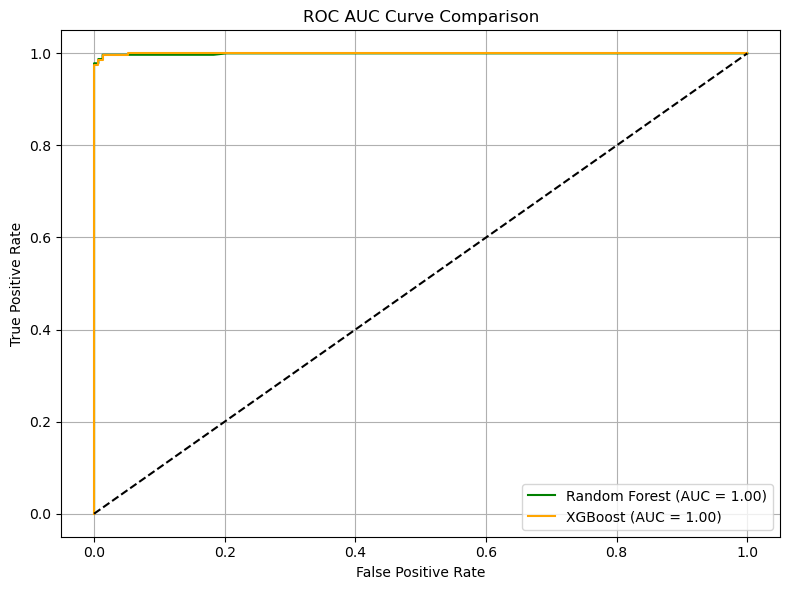

In [51]:
# ROC Curve
# Calculate FPR & TPR

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# Plot ROC Curve

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_proba_rf):.2f})', color='green')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb):.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC Curve Comparison")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [52]:
# Classification Report & Confusion Matrix
# Random Forest

print("Random Forest Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

# XGBoost

print("----------------------------------------------------------")
print("XGBoost Results")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Random Forest Results
Confusion Matrix:
 [[152   1]
 [  5 319]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       153
         1.0       1.00      0.98      0.99       324

    accuracy                           0.99       477
   macro avg       0.98      0.99      0.99       477
weighted avg       0.99      0.99      0.99       477

----------------------------------------------------------
XGBoost Results
Confusion Matrix:
 [[151   2]
 [  4 320]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       153
         1.0       0.99      0.99      0.99       324

    accuracy                           0.99       477
   macro avg       0.98      0.99      0.99       477
weighted avg       0.99      0.99      0.99       477



### Comments based on ROC Curve and Classification Report & Confusion Matrix

1. ROC AUC Curve (Model Discrimination Power)
    * Both Random Forest and XGBoost models achieved an AUC score of 1.00, indicating perfect discrimination between attrited and non-attrited drivers.

    * This level of separation shows that the models are extremely effective in ranking predictions by confidence.

    * Visually, the ROC curves are nearly identical and hug the top-left corner, which reflects very low false positive rates and high true positive rates.

    * Comment: While this looks excellent, AUC = 1.00 may sometimes suggest overfitting — ensure the models generalize well by checking on different cross-validation folds or unseen datasets.

2. Classification Report & Confusion Matrix
    * Random Forest
        - Accuracy: 99%

        - Precision (Class 1 - Attrition): 99%

        - Recall (Class 1): 98%

        - Confusion Matrix:

            * True Positives (TP): 319

            * False Positives (FP): 2

            * False Negatives (FN): 5

    * XGBoost
        - Accuracy: 99%

        - Precision (Class 1 - Attrition): 99%

        - Recall (Class 1): 99%

        - Confusion Matrix:

            * TP: 320

            * FP: 2

            * FN: 4

3. Comment:

    * Both models are excellent, but XGBoost slightly outperforms Random Forest in recall for the attrition class, which is critical in real-world HR or driver retention tasks (missing an actual attrition case is costlier than predicting one incorrectly).

    * False Positives are minimal in both models, ensuring minimal over-intervention in non-attrition cases.

# 5. Actionable Insights & Recommendations

1. Identify and Prioritize Drivers at Risk of Attrition
    * Use the trained XGBoost model to generate attrition probabilities for current drivers.

    * Focus on drivers with high attrition scores for early intervention.

    * These predictions can power internal dashboards for HR or Ops teams.

    * Recommendation: Create an alert system for drivers with attrition probability > 0.7 and flag them for follow-up by driver engagement teams.

2. Monitor Key Attrition Indicators
    * From your feature engineering and model importance, the following factors are likely influencing attrition:

    * Low Performance Rating / Band

    * Short Tenure (Seniority < 6 months)

    * Negative or Low Business Value (Loss-generating drivers)

    * Low Income Bucket

    * Recommendation:

        - Design targeted programs for new joiners and underperformers (e.g., onboarding boosters, refresher trainings).

        - Provide performance incentives or bonuses for drivers with increasing tenure or revenue.

3. Improve Driver Support Based on Income & Tenure
    * Drivers in the Low Income Bucket and early in their tenure are more likely to churn.

    * Recommendation:

        - Offer minimum guarantee schemes or early-tenure incentives to reduce the dip in earnings during ramp-up period.

        - Assign mentors or senior drivers to new joiners.

4. Use Attrition Predictions in Driver Lifecycle Management
    * Use attrition predictions to:

    * Time outreach campaigns (SMS, in-app messages)

    * Prioritize drivers for check-ins or benefits

    * Restructure schedules or loads for high-risk drivers

    * Recommendation:

        - Integrate model outputs into CRM tools to enable proactive, personalized interventions.

5. Design Exit Prevention Interventions
    * Recommendation:

        - For high-risk drivers flagged by the model:

        - Conduct 1:1 calls or surveys to understand pain points

        - Offer retention perks like fuel vouchers or performance bonuses

        - Adjust workloads or reassign preferred routes

6. Create a Continuous Feedback Loop
    * Periodically retrain the model on updated data (every 1–2 months).

    * Measure the effectiveness of interventions (e.g., reduction in attrition in flagged cohort).

    * Recommendation:

        - Track attrition over time using cohort analysis.

        - Build a simple driver risk dashboard to monitor changes in attrition probability.